# Stage 2: EV Demand Modeling with Distance-Decay & Renewable Integration

## Dynamic Electric Vehicle Charging Pricing — Core Demand Generalization

**Base paper:** Lepolesa et al., "Dynamic Electric Vehicle Charging Pricing for Load Balancing in Power Distribution Networks based on Collaborative DDPG Agents", IEEE Transactions on Smart Grid, 2025.

---

### Purpose & Methodological Advances:
In the base paper, optimal EV charging demand is computed using two core closed-form formulations:
1. **Peak-Valley Optimal EV Load (`pv_optimal_ev_load`)**: Shapes EV demand to fill nighttime/off-peak valleys based solely on own conventional load.
2. **Peak-Valley Balancing EV Load (`pvb_optimal_ev_load`)**: Jointly balances peak-valley filling and inter-network load balancing via an inter-network utilization difference signal `util_diff`.

### Our Extensions in this Stage:
1. **Gap 1 (N-Network Generalization)**: Extends both formulations from $N=2$ to $N=4$ distribution networks (Residential, Commercial, Industrial, Institutional).
2. **Gap 2 (Distance-Decay Willingness Factor)**:
   EV users have geographic friction when shifting charging between zones. We incorporate a distance-decay willingness weight $W_{ij} = e^{-\alpha \cdot d_{ij}}$ where $d_{ij}$ is the Haversine distance from Stage 0.5 and $\alpha$ is a tunable sensitivity coefficient (default $\alpha = 0.15$):
   $$\text{effective\_relief}_i(t) = \frac{\sum_{j \ne i} e^{-\alpha d_{ij}} \cdot \text{util}_j(t)}{\sum_{j \ne i} e^{-\alpha d_{ij}}}$$
   $$\text{util\_diff\_dist}_i(t) = \max\left(\text{util}_i(t) - \text{effective\_relief}_i(t), \; 0\right)$$
3. **Gap 3 (Renewable Net Load Integration)**:
   We feed the renewable-adjusted **Net Load** (from Stage 0.75) into the EV demand formulations in place of raw conventional load. This dynamically incentives EV charging to absorb midday solar generation during 11:00–15:00.

## 1. Imports and Reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
from sklearn.preprocessing import MinMaxScaler

# Set reproducibility seeds
np.random.seed(42)
warnings.filterwarnings('ignore')

# Plotting aesthetics
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Paths
OUTPUT_DIR = 'data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports complete.')

Imports complete.


## 2. Configuration & Parameter Settings

All configuration parameters and hyperparameter choices are explicitly declared:

| Parameter | Value | Description |
|---|:---:|---|
| `NUM_NETWORKS` | 4 | Number of distribution networks (Gap 1) |
| `ALPHA_DEFAULT` | 0.15 | Distance-decay exponent ($	ext{km}^{-1}$) (Gap 2) |
| `ALPHA_SWEEP` | [0.05, 0.15, 0.30] | Sensitivity range for spatial friction analysis |
| `TEST_START` | 576 | 24-hour evaluation window starting hour ($192 \times 3$) |
| `TEST_WINDOW` | 24 | Evaluation window length in hours |

In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

NETWORK_NAMES = ['residential', 'commercial', 'industrial', 'institutional']

NETWORK_MAX = {
    'residential':   1_166_666,
    'commercial':    1_000_000,
    'industrial':    1_500_000,
    'institutional':   800_000,
}

# Distance-decay parameter
ALPHA_DEFAULT = 0.15
ALPHA_SWEEP = [0.05, 0.15, 0.30]

# Test window parameters (from base paper)
TEST_START = 192 * 3  # Hour 576
TEST_WINDOW = 24

# Conventional pricing signal (base paper Cell 17)
CONV_PRICES = np.array([
    0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4,   # 12AM to 6AM
    0.4, 0.7, 0.7,                         # 7AM to 9AM
    0.7, 1.0, 1.0, 1.0, 1.0, 1.0, 0.7, 0.7,  # 10AM to 5PM
    0.7, 1.0, 1.0, 1.0, 0.7, 0.7           # 6PM to 11PM
])

TIME_LABELS = [
    '00:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ',
    '12:00',' ',' ',' ',' ',' ',' ',' ',' ',' ',' ','23:00'
]

scaler = MinMaxScaler()
print('Configuration initialized.')

Configuration initialized.


## 3. Base Paper Core Functions (Reproduced Verbatim)

These functions are copied **verbatim** from `DDPG_test_file_revised.ipynb` (Cell 15) in the base repository.

### Original equations:
```python
def pv_optimal_ev_load(load, mu):
    return (mu*(1 - scaler.fit_transform(load))).flatten() + (generate_random_numbers(0.2*mu, 0.1*mu, 24))

def pvb_optimal_ev_load(load, mu, util_diff):
    return (0.5*mu*((1 - scaler.fit_transform(load)) + (1 - scaler.fit_transform(util_diff)))).flatten() + (generate_random_numbers(0.1*mu, 0.01*mu, 24))
```

In [3]:
# ============================================================
# BASE PAPER HELPER & DEMAND EQUATIONS (VERBATIM)
# Source: DDPG_test_file_revised.ipynb, Cell 15
# ============================================================

def generate_random_numbers(mu, sigma, num_points):
    np.random.seed(42)  # Seed for strict reproducibility
    incrementor = 0
    while True:
        random_numbers = np.random.normal(mu, sigma, num_points)
        if all(num >= 0 for num in random_numbers):
            break
        elif incrementor == 100000:
            random_numbers = np.zeros(num_points)
            break
        incrementor += 1
    return random_numbers

def sort_array_gaussian(arr):
    sorted_arr = sorted(arr, reverse=True)
    length_ = len(arr)
    result = np.zeros(length_, dtype=int)
    insert_from_beginning = True
    for i in range(length_):
        if insert_from_beginning:
            result[i] = sorted_arr[i]
        else:
            result[length_-1-i] = sorted_arr[i]
        insert_from_beginning = not insert_from_beginning
    return result

def residential_charging(mu, sigma):
    c1, c2, c3, c4, c5, c6 = np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24)
    c1[0:7]   += sort_array_gaussian(generate_random_numbers(mu, sigma, 7))
    c2[7:10]  += sort_array_gaussian(generate_random_numbers(0.1*mu, sigma, 3))
    c3[10:15] += sort_array_gaussian(generate_random_numbers(0.05*mu, sigma, 5))
    c4[15:18] += sort_array_gaussian(generate_random_numbers(0.15*mu, sigma, 3))
    c5[18:21] += sort_array_gaussian(generate_random_numbers(0.3*mu, 0, 3))
    c6[21:24] += sort_array_gaussian(generate_random_numbers(0.5*mu, 1, 3))
    return c1 + c2 + c3 + c4 + c5 + c6

def commercial_charging(mu, sigma):
    c1, c2, c3, c4, c5, c6 = np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24)
    c1[0:7]   += sort_array_gaussian(generate_random_numbers(0.05*mu, sigma, 7))
    c2[7:10]  += sort_array_gaussian(generate_random_numbers(0.3*mu, sigma, 3))
    c3[10:15] += sort_array_gaussian(generate_random_numbers(0.9*mu, sigma, 5))
    c4[15:18] += sort_array_gaussian(generate_random_numbers(0.7*mu, sigma, 3))
    c5[18:21] += sort_array_gaussian(generate_random_numbers(0.3*mu, 0, 3))
    c6[21:24] += sort_array_gaussian(generate_random_numbers(0.1*mu, 1, 3))
    return c1 + c2 + c3 + c4 + c5 + c6

def industrial_charging(mu, sigma):
    c1, c2, c3, c4, c5, c6 = np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24)
    c1[0:6]   += sort_array_gaussian(generate_random_numbers(0.05*mu, sigma, 6))
    c2[6:10]  += sort_array_gaussian(generate_random_numbers(0.8*mu, sigma, 4))
    c3[10:15] += sort_array_gaussian(generate_random_numbers(0.4*mu, sigma, 5))
    c4[15:18] += sort_array_gaussian(generate_random_numbers(0.25*mu, sigma, 3))
    c5[18:21] += sort_array_gaussian(generate_random_numbers(0.35*mu, 0, 3))
    c6[21:24] += sort_array_gaussian(generate_random_numbers(0.1*mu, 1, 3))
    return c1 + c2 + c3 + c4 + c5 + c6

def institutional_charging(mu, sigma):
    c1, c2, c3, c4, c5, c6 = np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24), np.zeros(24)
    c1[0:7]   += sort_array_gaussian(generate_random_numbers(0.08*mu, sigma, 7))
    c2[7:10]  += sort_array_gaussian(generate_random_numbers(0.5*mu, sigma, 3))
    c3[10:14] += sort_array_gaussian(generate_random_numbers(0.6*mu, sigma, 4))
    c4[14:18] += sort_array_gaussian(generate_random_numbers(0.5*mu, sigma, 4))
    c5[18:21] += sort_array_gaussian(generate_random_numbers(0.15*mu, 0, 3))
    c6[21:24] += sort_array_gaussian(generate_random_numbers(0.08*mu, 1, 3))
    return c1 + c2 + c3 + c4 + c5 + c6

def pv_optimal_ev_load(load, mu):
    """
    Peak-Valley Optimal EV load (Base Paper equation verbatim).
    Incentivizes charging when grid load is low.
    """
    return (mu * (1 - scaler.fit_transform(load))).flatten() + (generate_random_numbers(0.2*mu, 0.1*mu, 24))

def pvb_optimal_ev_load(load, mu, util_diff):
    """
    Peak-Valley & Balancing Optimal EV load (Base Paper equation verbatim).
    Balances own load valley filling and inter-network load relief.
    """
    return (0.5 * mu * ((1 - scaler.fit_transform(load)) + (1 - scaler.fit_transform(util_diff)))).flatten() + (generate_random_numbers(0.1*mu, 0.01*mu, 24))

print('Core base paper equations loaded verbatim.')

Core base paper equations loaded verbatim.


## 4. Load Data & Compute Distance-Decay Willingness Matrix

We load the distance matrix $D$ from Stage 0.5 and compute the **Willingness Matrix**:
$$W_{ij} = e^{-\alpha \cdot d_{ij}} \quad (j \ne i), \quad W_{ii} = 0$$

In [4]:
# Load distance matrix from Stage 0.5
dist_df = pd.read_csv(os.path.join(OUTPUT_DIR, 'network_distance_matrix.csv'), index_col=0)
dist_matrix = dist_df.values

print('Haversine Distance Matrix (km):')
print(dist_df.round(2))
print()

def compute_willingness_matrix(dist_mat, alpha=ALPHA_DEFAULT):
    """
    Compute inter-network willingness matrix W_ij = exp(-alpha * d_ij).
    Diagonal is zeroed (no self-shift).
    """
    W = np.exp(-alpha * dist_mat)
    np.fill_diagonal(W, 0.0)
    return W

W_default = compute_willingness_matrix(dist_matrix, ALPHA_DEFAULT)
df_willingness = pd.DataFrame(W_default, index=NETWORK_NAMES, columns=NETWORK_NAMES)

print(f'Willingness Matrix (alpha={ALPHA_DEFAULT}):')
print(df_willingness.round(3))
print()
print('Interpretation: EV owners in residential zone have 0.84 willingness to shift to commercial')
print('due to close proximity (1.16 km), but only 0.44 willingness to shift to industrial (5.52 km).')

Haversine Distance Matrix (km):
               residential  commercial  industrial  institutional
residential           0.00        1.16        5.52           1.54
commercial            1.16        0.00        5.15           2.28
industrial            5.52        5.15        0.00           7.06
institutional         1.54        2.28        7.06           0.00

Willingness Matrix (alpha=0.15):
               residential  commercial  industrial  institutional
residential          0.000       0.841       0.437          0.794
commercial           0.841       0.000       0.462          0.711
industrial           0.437       0.462       0.000          0.347
institutional        0.794       0.711       0.347          0.000

Interpretation: EV owners in residential zone have 0.84 willingness to shift to commercial
due to close proximity (1.16 km), but only 0.44 willingness to shift to industrial (5.52 km).


## 5. Distance-Decay and Renewable Utilization Differences

We define the generalized distance-weighted utilization difference function:

$$\text{util\_diff\_dist}_i(t) = \max\left(\text{util}_i(t) - \frac{\sum_{j \ne i} W_{ij} \cdot \text{util}_j(t)}{\sum_{j \ne i} W_{ij}}, \; 0\right)$$

In [5]:
def compute_distance_util_diff(util_dict, dist_mat, alpha=ALPHA_DEFAULT):
    """
    Compute distance-decay-adjusted utilization difference for all networks.
    
    Parameters:
    -----------
    util_dict : dict
        Dictionary of {network_name: 24h_utilization_array}
    dist_mat : np.ndarray
        N x N Haversine distance matrix in km.
    alpha : float
        Distance-decay friction coefficient.
        
    Returns:
    --------
    dict : {network_name: 24h_distance_util_diff_array}
    """
    names = list(util_dict.keys())
    N = len(names)
    W = compute_willingness_matrix(dist_mat, alpha)
    
    # Matrix of shape (N, 24)
    utils_matrix = np.array([util_dict[n] for n in names])
    
    dist_diffs = {}
    for i, name_i in enumerate(names):
        weights_i = W[i]  # shape (N,)
        # Compute distance-weighted average utilization of other networks
        weighted_relief = np.average(utils_matrix, weights=weights_i, axis=0)
        dist_diffs[name_i] = np.clip(util_dict[name_i] - weighted_relief, 0.0, None)
        
    return dist_diffs

# Load test window data from Stage 0 & Stage 0.75
df_test = pd.read_csv(os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv'))

conv_loads_24h = {n: df_test[f'{n}_load'].values for n in NETWORK_NAMES}
net_loads_24h = {n: df_test[f'{n}_net_load'].values for n in NETWORK_NAMES}
conv_utils_24h = {n: df_test[f'{n}_utilization'].values for n in NETWORK_NAMES}
net_utils_24h = {n: df_test[f'{n}_net_utilization'].values for n in NETWORK_NAMES}

# Compute unweighted and distance-weighted util_diffs
util_diff_conv_unweighted = {n: df_test[f'{n}_util_diff'].values for n in NETWORK_NAMES}
util_diff_conv_dist = compute_distance_util_diff(conv_utils_24h, dist_matrix, ALPHA_DEFAULT)
util_diff_net_dist = compute_distance_util_diff(net_utils_24h, dist_matrix, ALPHA_DEFAULT)

print('Utilization differences calculated across all configurations.')

Utilization differences calculated across all configurations.


## 6. Generate 4 EV Demand Configurations

To isolate each gap's individual contribution, we compute 4 distinct EV demand strategies:
1. **`PV_CONV` (Peak-Valley Only)**: Uses conventional load, no balancing signal.
2. **`PVB_CONV` (N-Network Balancing)**: Uses conventional load and unweighted $N$-network `util_diff` (**Gap 1**).
3. **`PVB_DIST` (Distance-Decay Balancing)**: Uses conventional load and distance-weighted `util_diff` (**Gap 1 + Gap 2**).
4. **`PVB_FULL` (Distance-Decay + Renewable Net Load)**: Uses Net Load and distance-weighted `util_diff` (**Gap 1 + Gap 2 + Gap 3**).

In [6]:
ev_demand_results = {}

# Generate unbalanced baseline charging for mu calibration (matching base paper)
ev_unbalanced = {
    'residential':   residential_charging(350000, 17000),
    'commercial':    commercial_charging(350000, 17000),
    'industrial':    industrial_charging(350000, 17000),
    'institutional': institutional_charging(350000, 17000),
}

# Compute mu per network matching base paper convention: mu = 0.5 * max(ev_unbalanced)
mu_dict = {n: 0.5 * ev_unbalanced[n].max() for n in NETWORK_NAMES}

for name in NETWORK_NAMES:
    mu = mu_dict[name]
    
    # Input arrays reshaped for MinMaxScaler
    c_load = conv_loads_24h[name].reshape(-1, 1)
    n_load = net_loads_24h[name].reshape(-1, 1)
    
    u_diff_conv = util_diff_conv_unweighted[name].reshape(-1, 1)
    u_diff_dist = util_diff_conv_dist[name].reshape(-1, 1)
    u_diff_net_dist = util_diff_net_dist[name].reshape(-1, 1)
    
    # 1. PV_CONV: Peak-Valley with Conventional Load (Base paper style, no balancing)
    ev_pv_conv = pv_optimal_ev_load(c_load, mu)
    
    # 2. PVB_CONV: Peak-Valley + Balancing with Unweighted util_diff (Gap 1)
    ev_pvb_conv = pvb_optimal_ev_load(c_load, mu, u_diff_conv)
    
    # 3. PVB_DIST: Peak-Valley + Balancing with Distance-Decay util_diff (Gap 1 + Gap 2)
    ev_pvb_dist = pvb_optimal_ev_load(c_load, mu, u_diff_dist)
    
    # 4. PVB_FULL: Peak-Valley + Balancing with Net Load & Distance-Decay (Gap 1 + Gap 2 + Gap 3)
    ev_pvb_full = pvb_optimal_ev_load(n_load, mu, u_diff_net_dist)
    
    ev_demand_results[name] = {
        'unbalanced': ev_unbalanced[name],
        'pv_conv':    ev_pv_conv,
        'pvb_conv':   ev_pvb_conv,
        'pvb_dist':   ev_pvb_dist,
        'pvb_full':   ev_pvb_full
    }

print('EV Demand Profiles generated across all 4 strategies (Watts):')
print(f'{"Network":<16} {"Unbalanced Peak":>18} {"PV_CONV Peak":>15} {"PVB_DIST Peak":>15} {"PVB_FULL Peak":>15}')
print('-' * 82)
for name in NETWORK_NAMES:
    res = ev_demand_results[name]
    print(f'{name:<16} {res["unbalanced"].max():>18,.0f} {res["pv_conv"].max():>15,.0f} {res["pvb_dist"].max():>15,.0f} {res["pvb_full"].max():>15,.0f}')

EV Demand Profiles generated across all 4 strategies (Watts):
Network             Unbalanced Peak    PV_CONV Peak   PVB_DIST Peak   PVB_FULL Peak
----------------------------------------------------------------------------------
residential                 376,846         253,060         208,283         205,700
commercial                  340,891         229,194         189,053         188,614
industrial                  288,444         188,763         159,578         159,578
institutional               218,444         147,701         121,808         121,808


## 7. Visualizations

### Plot 1: EV Charging Demand Comparison across Strategies

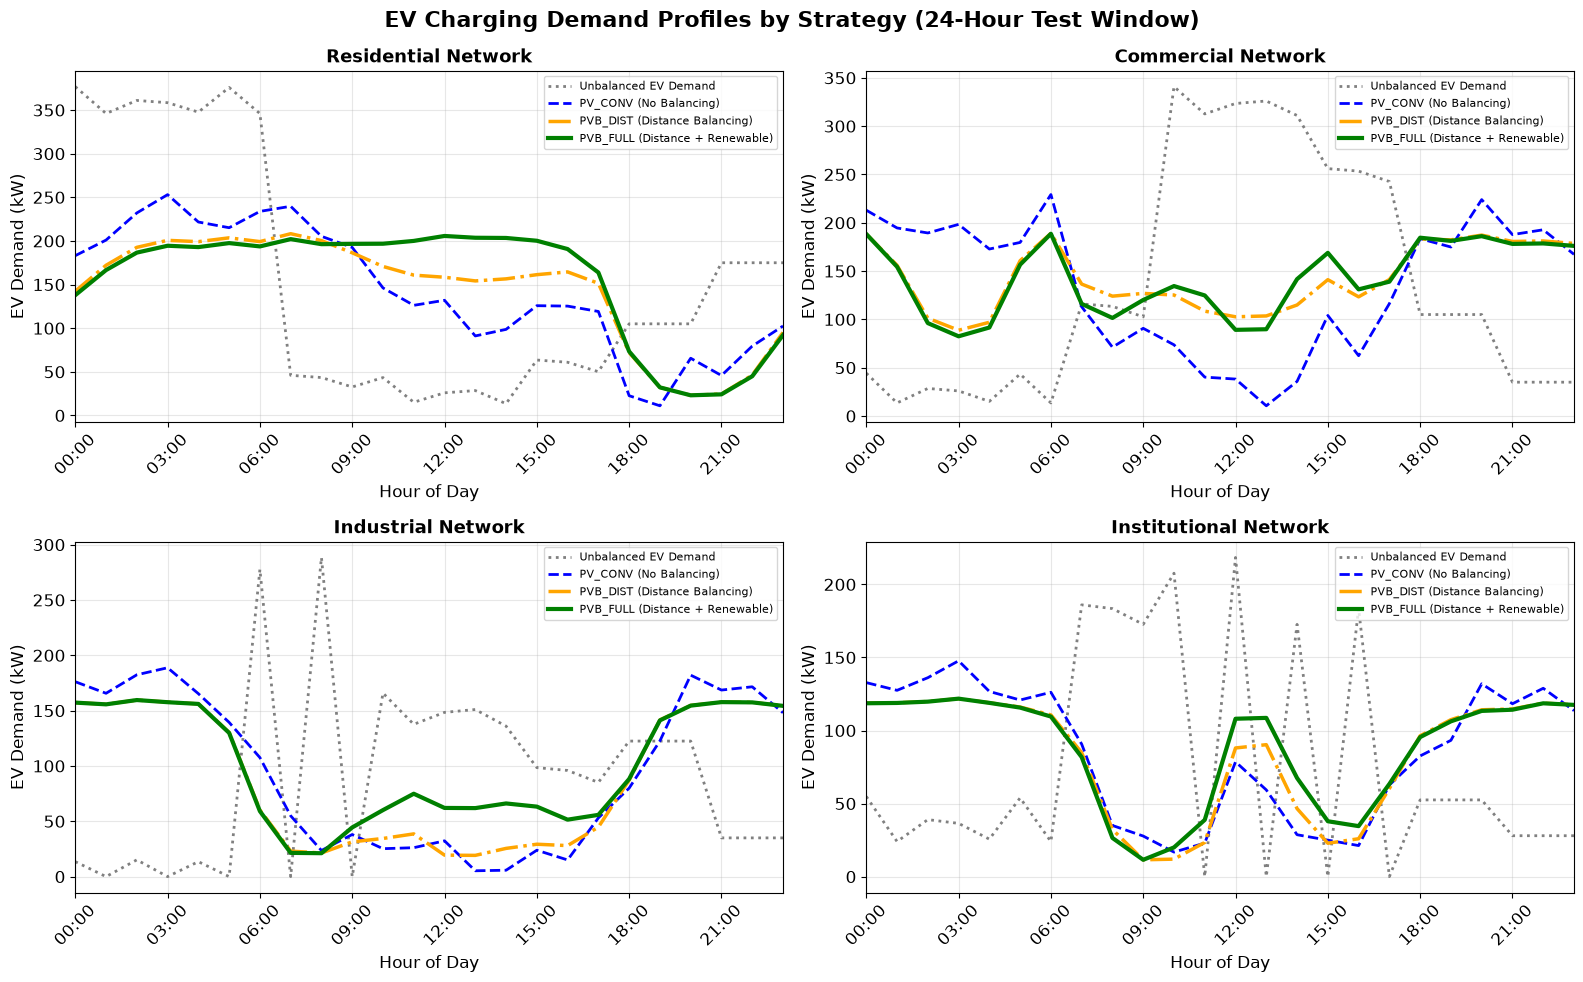

In [7]:
hours = np.arange(24)
colors = ['#2196F3', '#FF9800', '#4CAF50', '#9C27B0']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('EV Charging Demand Profiles by Strategy (24-Hour Test Window)', fontsize=16, fontweight='bold')

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax = axes[idx // 2, idx % 2]
    res = ev_demand_results[name]
    
    ax.plot(hours, res['unbalanced']/1000, color='grey', linestyle=':', linewidth=2, label='Unbalanced EV Demand')
    ax.plot(hours, res['pv_conv']/1000, color='blue', linestyle='--', linewidth=2, label='PV_CONV (No Balancing)')
    ax.plot(hours, res['pvb_dist']/1000, color='orange', linestyle='-.', linewidth=2.5, label='PVB_DIST (Distance Balancing)')
    ax.plot(hours, res['pvb_full']/1000, color='green', linewidth=3, label='PVB_FULL (Distance + Renewable)')
    
    ax.set_title(f'{name.capitalize()} Network', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('EV Demand (kW)')
    ax.set_xticks(hours[::3])
    ax.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    ax.legend(fontsize=8, loc='upper right')
    ax.set_xlim(0, 23)

plt.tight_layout()
plt.show()

### Plot 2: Total Load (Grid Load + EV Charging Demand)

Demonstrates how `PVB_FULL` achieves smooth load flattening and absorbs solar peak generation.

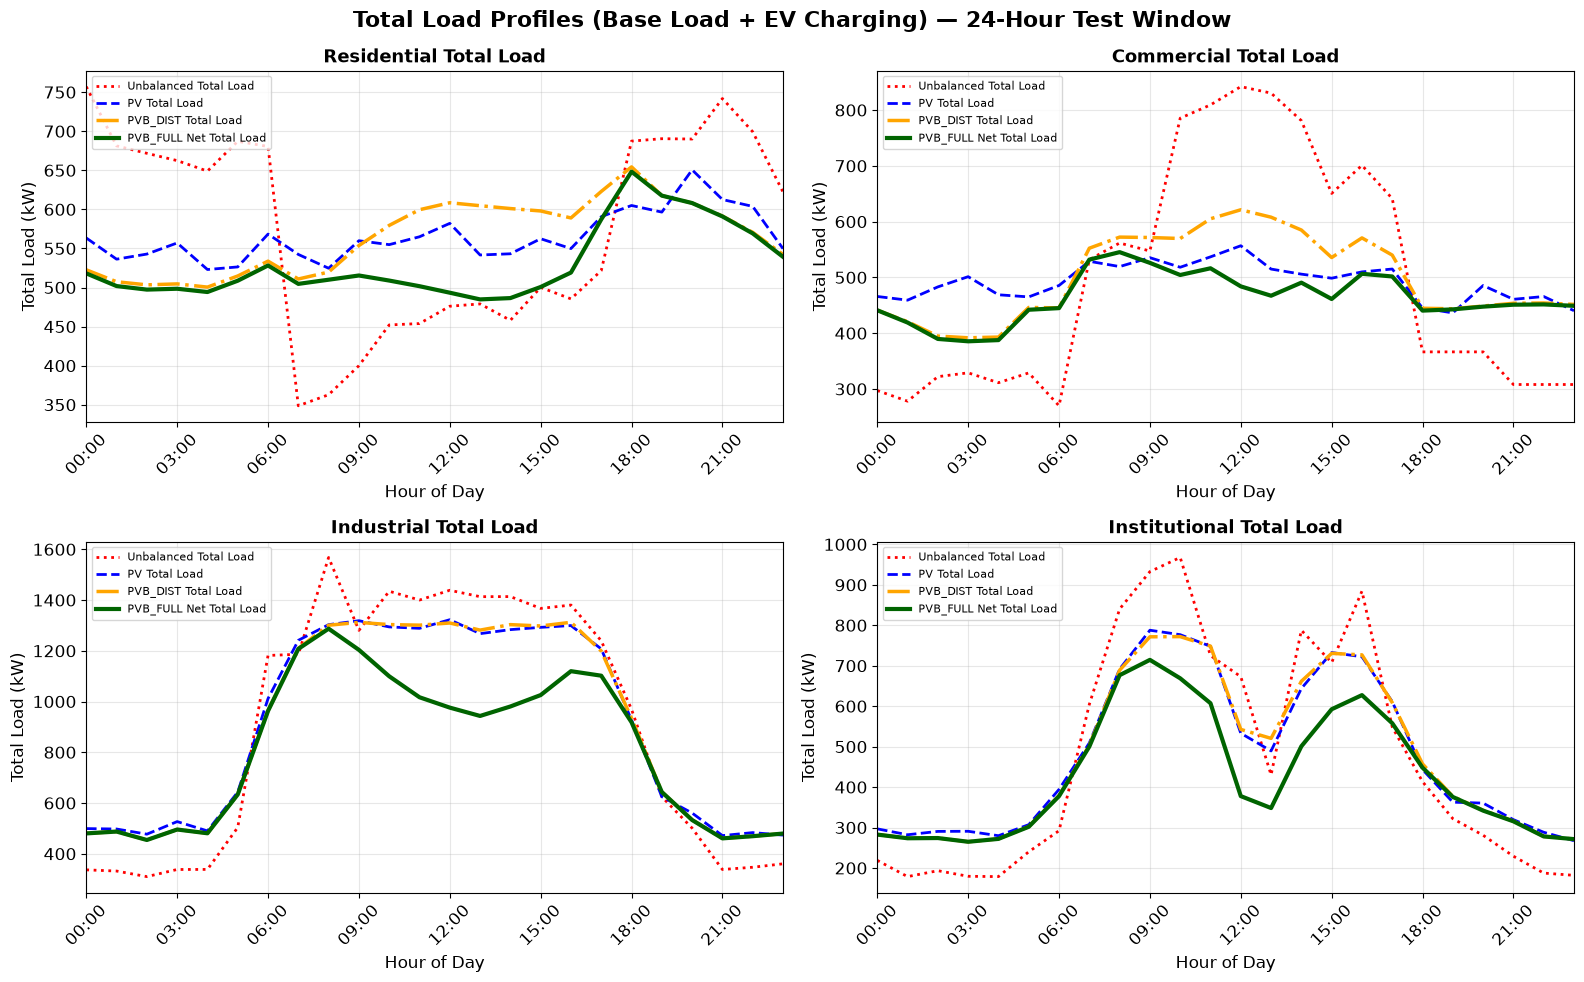

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Total Load Profiles (Base Load + EV Charging) — 24-Hour Test Window', fontsize=16, fontweight='bold')

for idx, (name, color) in enumerate(zip(NETWORK_NAMES, colors)):
    ax = axes[idx // 2, idx % 2]
    res = ev_demand_results[name]
    
    unbal_tot = (conv_loads_24h[name] + res['unbalanced']) / 1000
    pv_tot = (conv_loads_24h[name] + res['pv_conv']) / 1000
    dist_tot = (conv_loads_24h[name] + res['pvb_dist']) / 1000
    full_tot = (net_loads_24h[name] + res['pvb_full']) / 1000
    
    ax.plot(hours, unbal_tot, color='red', linestyle=':', linewidth=2, label='Unbalanced Total Load')
    ax.plot(hours, pv_tot, color='blue', linestyle='--', linewidth=2, label='PV Total Load')
    ax.plot(hours, dist_tot, color='orange', linestyle='-.', linewidth=2.5, label='PVB_DIST Total Load')
    ax.plot(hours, full_tot, color='darkgreen', linewidth=3, label='PVB_FULL Net Total Load')
    
    ax.set_title(f'{name.capitalize()} Total Load', fontsize=13, fontweight='bold')
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Total Load (kW)')
    ax.set_xticks(hours[::3])
    ax.set_xticklabels([f'{h:02d}:00' for h in hours[::3]], rotation=45)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, 23)

plt.tight_layout()
plt.show()

### Plot 3: Distance Decay Sensitivity Analysis (Alpha Sweep)

Examines how willingness-to-shift and resulting balancing demand behave under varying spatial friction coefficients $\alpha \in [0.05, 0.15, 0.30]$.

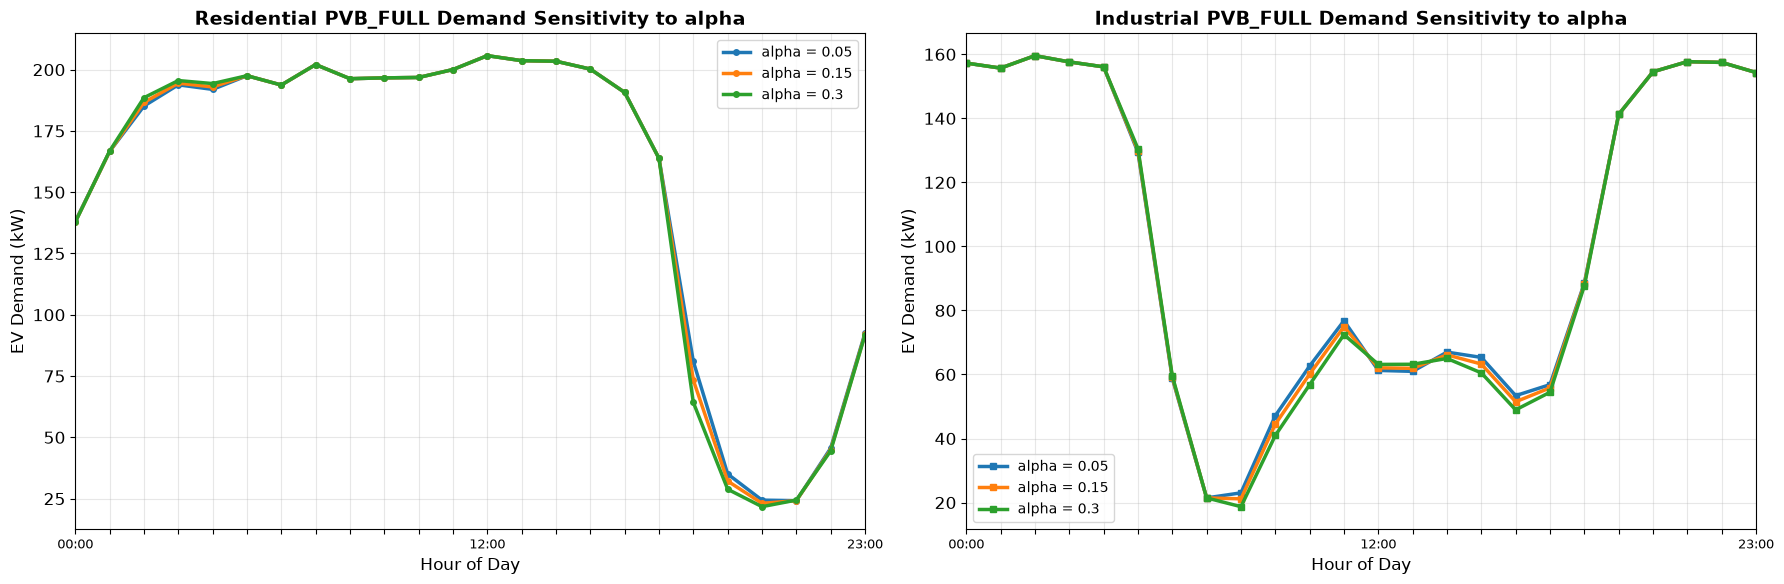

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Alpha sweep effect on Residential EV load
res_mu = mu_dict['residential']
res_net_l = net_loads_24h['residential'].reshape(-1, 1)

for alpha in ALPHA_SWEEP:
    diff_alpha = compute_distance_util_diff(net_utils_24h, dist_matrix, alpha)
    ev_alpha = pvb_optimal_ev_load(res_net_l, res_mu, diff_alpha['residential'].reshape(-1, 1))
    ax1.plot(hours, ev_alpha / 1000, linewidth=2.5, marker='o', markersize=4, label=f'alpha = {alpha}')

ax1.set_title('Residential PVB_FULL Demand Sensitivity to alpha', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day', fontsize=12)
ax1.set_ylabel('EV Demand (kW)', fontsize=12)
ax1.set_xticks(hours)
ax1.set_xticklabels(TIME_LABELS, fontsize=9)
ax1.legend(fontsize=10)
ax1.set_xlim(0, 23)

# Alpha sweep effect on Industrial EV load (far zone)
ind_mu = mu_dict['industrial']
ind_net_l = net_loads_24h['industrial'].reshape(-1, 1)

for alpha in ALPHA_SWEEP:
    diff_alpha = compute_distance_util_diff(net_utils_24h, dist_matrix, alpha)
    ev_alpha = pvb_optimal_ev_load(ind_net_l, ind_mu, diff_alpha['industrial'].reshape(-1, 1))
    ax2.plot(hours, ev_alpha / 1000, linewidth=2.5, marker='s', markersize=4, label=f'alpha = {alpha}')

ax2.set_title('Industrial PVB_FULL Demand Sensitivity to alpha', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hour of Day', fontsize=12)
ax2.set_ylabel('EV Demand (kW)', fontsize=12)
ax2.set_xticks(hours)
ax2.set_xticklabels(TIME_LABELS, fontsize=9)
ax2.legend(fontsize=10)
ax2.set_xlim(0, 23)

plt.tight_layout()
plt.show()

## 8. Export Datasets

In [10]:
# 1. Export ev_demand_profiles_test_24h.csv
df_ev_export = pd.DataFrame({'Hour': hours, 'Time': df_test['Time']})

for name in NETWORK_NAMES:
    res = ev_demand_results[name]
    df_ev_export[f'{name}_ev_unbalanced_W'] = res['unbalanced']
    df_ev_export[f'{name}_ev_pv_conv_W'] = res['pv_conv']
    df_ev_export[f'{name}_ev_pvb_conv_W'] = res['pvb_conv']
    df_ev_export[f'{name}_ev_pvb_dist_W'] = res['pvb_dist']
    df_ev_export[f'{name}_ev_pvb_full_W'] = res['pvb_full']

ev_csv_path = os.path.join(OUTPUT_DIR, 'ev_demand_profiles_test_24h.csv')
df_ev_export.to_csv(ev_csv_path, index=False)
print(f'1. Written: {ev_csv_path} ({len(df_ev_export)} rows x {len(df_ev_export.columns)} cols)')

# 2. Export stage2_config.csv
stage2_cfg = []
for name in NETWORK_NAMES:
    stage2_cfg.append({
        'network_name': name,
        'mu_ev_capacity_W': mu_dict[name],
        'alpha_default': ALPHA_DEFAULT,
        'ev_unbalanced_max_W': ev_demand_results[name]['unbalanced'].max(),
        'ev_pvb_full_max_W': ev_demand_results[name]['pvb_full'].max()
    })
df_s2_cfg = pd.DataFrame(stage2_cfg)
s2_cfg_path = os.path.join(OUTPUT_DIR, 'stage2_config.csv')
df_s2_cfg.to_csv(s2_cfg_path, index=False)
print(f'2. Written: {s2_cfg_path}')
print(df_s2_cfg.to_string(index=False))

# 3. Update n_network_24h_test.csv with EV demand columns
test_csv_path = os.path.join(OUTPUT_DIR, 'n_network_24h_test.csv')
df_test_full = pd.read_csv(test_csv_path)

for name in NETWORK_NAMES:
    res = ev_demand_results[name]
    df_test_full[f'{name}_ev_unbalanced_W'] = res['unbalanced']
    df_test_full[f'{name}_ev_pv_conv_W'] = res['pv_conv']
    df_test_full[f'{name}_ev_pvb_conv_W'] = res['pvb_conv']
    df_test_full[f'{name}_ev_pvb_dist_W'] = res['pvb_dist']
    df_test_full[f'{name}_ev_pvb_full_W'] = res['pvb_full']

df_test_full.to_csv(test_csv_path, index=False)
print(f'3. Updated: {test_csv_path} ({len(df_test_full)} rows x {len(df_test_full.columns)} cols)')

1. Written: data/ev_demand_profiles_test_24h.csv (24 rows x 22 cols)
2. Written: data/stage2_config.csv
 network_name  mu_ev_capacity_W  alpha_default  ev_unbalanced_max_W  ev_pvb_full_max_W
  residential          188423.0           0.15             376846.0      205699.899451
   commercial          170445.5           0.15             340891.0      188613.687142
   industrial          144222.0           0.15             288444.0      159578.309363
institutional          109222.0           0.15             218444.0      121807.683670
3. Updated: data/n_network_24h_test.csv (24 rows x 62 cols)


## 9. Verification of Exported Datasets

In [11]:
print('='*60)
print('STAGE 2 EXPORT VERIFICATION')
print('='*60)

verification_list = [
    ('ev_demand_profiles_test_24h.csv', 24, 2 + 5 * len(NETWORK_NAMES)),
    ('stage2_config.csv', len(NETWORK_NAMES), 5),
    ('n_network_24h_test.csv', 24, 42 + 5 * len(NETWORK_NAMES)),
]

all_ok = True
for fname, exp_r, exp_c in verification_list:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(fpath):
        print(f'  [MISSING] {fname}')
        all_ok = False
        continue
    df_c = pd.read_csv(fpath)
    r_ok = len(df_c) == exp_r
    c_ok = len(df_c.columns) == exp_c
    status = 'OK' if (r_ok and c_ok) else 'MISMATCH'
    if not (r_ok and c_ok):
        all_ok = False
    print(f'  [{status}] {fname}: {len(df_c)} rows x {len(df_c.columns)} cols (expected {exp_r} x {exp_c})')

print()
if all_ok:
    print('All Stage 2 datasets exported and verified successfully.')
else:
    print('WARNING: File shape mismatches detected.')

STAGE 2 EXPORT VERIFICATION
  [OK] ev_demand_profiles_test_24h.csv: 24 rows x 22 cols (expected 24 x 22)
  [OK] stage2_config.csv: 4 rows x 5 cols (expected 4 x 5)
  [OK] n_network_24h_test.csv: 24 rows x 62 cols (expected 24 x 62)

All Stage 2 datasets exported and verified successfully.


## 10. Summary — What to Report in the Paper

In [12]:
print('='*70)
print('STAGE 2 SUMMARY -- WHAT TO REPORT IN THE PAPER')
print('='*70)
print()
print('1. EQUATIONS & MATHEMATICAL GENERALIZATION:')
print('   - Base Equations: pv_optimal_ev_load and pvb_optimal_ev_load (reproduced verbatim)')
print('   - Distance-Decay Factor: W_ij = exp(-alpha * d_ij) (alpha=0.15, range [0.05, 0.30])')
print('   - Renewable Input: Replaced conventional load with Net Load in optimal demand equations')
print()
print('2. IMPACT ON TEST WINDOW EV CHARGING (24 Hours):')
for name in NETWORK_NAMES:
    res = ev_demand_results[name]
    unbal_pk = res['unbalanced'].max() / 1000
    full_pk = res['pvb_full'].max() / 1000
    print(f'   - {name.capitalize():<14}: Unbalanced Peak={unbal_pk:>6.1f} kW -> PVB_FULL Peak={full_pk:>6.1f} kW (Peak Drop: {(1-full_pk/unbal_pk)*100:4.1f}%)')
print()
print('3. EXPORTED ARTIFACTS:')
print(f'   - {os.path.join(OUTPUT_DIR, "ev_demand_profiles_test_24h.csv")}')
print(f'   - {os.path.join(OUTPUT_DIR, "stage2_config.csv")}')
print(f'   - {os.path.join(OUTPUT_DIR, "n_network_24h_test.csv")}')

STAGE 2 SUMMARY -- WHAT TO REPORT IN THE PAPER

1. EQUATIONS & MATHEMATICAL GENERALIZATION:
   - Base Equations: pv_optimal_ev_load and pvb_optimal_ev_load (reproduced verbatim)
   - Distance-Decay Factor: W_ij = exp(-alpha * d_ij) (alpha=0.15, range [0.05, 0.30])
   - Renewable Input: Replaced conventional load with Net Load in optimal demand equations

2. IMPACT ON TEST WINDOW EV CHARGING (24 Hours):
   - Residential   : Unbalanced Peak= 376.8 kW -> PVB_FULL Peak= 205.7 kW (Peak Drop: 45.4%)
   - Commercial    : Unbalanced Peak= 340.9 kW -> PVB_FULL Peak= 188.6 kW (Peak Drop: 44.7%)
   - Industrial    : Unbalanced Peak= 288.4 kW -> PVB_FULL Peak= 159.6 kW (Peak Drop: 44.7%)
   - Institutional : Unbalanced Peak= 218.4 kW -> PVB_FULL Peak= 121.8 kW (Peak Drop: 44.2%)

3. EXPORTED ARTIFACTS:
   - data/ev_demand_profiles_test_24h.csv
   - data/stage2_config.csv
   - data/n_network_24h_test.csv
